In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [2]:
data=pd.read_csv("/content/medical_insurance.csv")
print(data.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [4]:
smoker=data['smoker'].value_counts()
smoker

#Number of children covered by health insurance / Number of dependents
children=data['children'].value_counts()

In [5]:
data['age']=data['age'].fillna(data['age'].mean())

In [6]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data['sex'] = encoder.fit_transform(data['sex'])
data['smoker'] = encoder.fit_transform(data['smoker'])

In [7]:
data.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.90,0,1,southwest,16884.9240
1,18,1,33.77,1,0,southeast,1725.5523


In [8]:
X = data[['age', 'sex', 'bmi',
           'children', 'smoker', 'region']]

y=data['charges']

In [9]:
X = pd.get_dummies(
    X,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=37)
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [11]:
predict=model.predict(X_test)

In [12]:
model.coef_

array([  259.02580604,   340.48812372,   502.3091664 ,   -80.9270308 ,
       24038.5517561 ,   165.96583069,  -967.58137617,  -777.42840099])

In [13]:
model.intercept_

np.float64(-12397.625384278115)

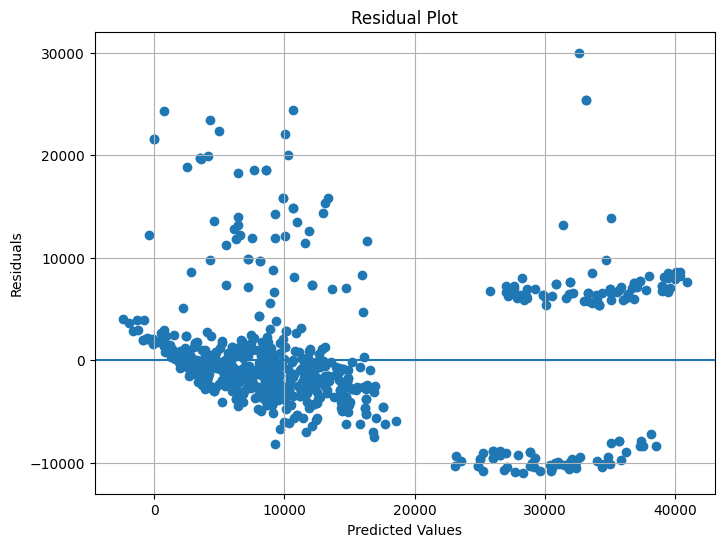

In [14]:
residuals = y_test - predict

plt.figure(figsize=(8,6))

plt.scatter(predict, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)
plt.show()

In [15]:
r2_score(y_test,predict)

0.7338509444116883

In [16]:
mean_squared_error(y_test,predict)

39847179.867819294

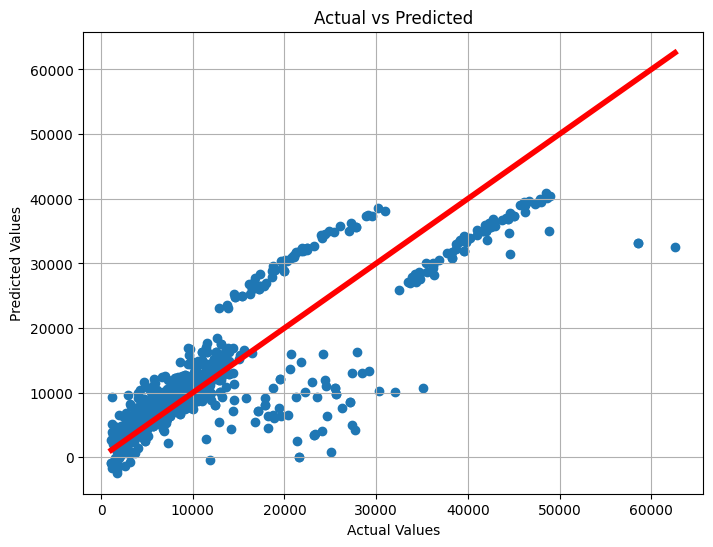

In [17]:
# Plot
plt.figure(figsize=(8,6))

plt.scatter(y_test, predict)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=4,color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

In [18]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.7562932384475212
0.7338509444116883


# Gradient Descent


In [94]:
class GDRegressor:

    def __init__(self,learning_rate=0.01,epochs=100):

        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X_train,y_train):

        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):

            y_hat = np.dot(X_train,self.coef_) + self.intercept_

            intercept_der = -2 * np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ - (self.lr * intercept_der)

            coef_der = -2 * np.dot((y_train - y_hat),X_train)/X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_der)

        print(self.intercept_,self.coef_)

    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [100]:
gdr = GDRegressor(epochs=1000,learning_rate=0.01)

In [101]:
gdr.fit(X_train,y_train)

13220.925894579339 [3684.99155168 2071.93011079  612.74794461  -40.4567494  9677.26905449
   72.77045561 -432.27933933 -334.70939416]


In [102]:
y_predict=gdr.predict(X_test)

In [103]:
r2_score(y_test,y_predict)

0.7338441410499013